# Neural Nets for Regression and Classification

This lecture is about the common *output layers* of neural networks built for
regression and classification, and the loss functions used to optimize them.

## Regression

* **Output Layer Structure**: The output layer typically consists of one or more nodes with no activation function, effectively performing a linear combination of the features extracted by previous layers.
* **Multiple Outputs**: Multiple output nodes allow the network to regress on several functions simultaneously using the same input data. While these nodes share underlying features, they combine them differently to fit their respective targets.
* **Loss Function**: These networks are standardly trained using **Squared Error**.
* **Implementation Note**: While often referred to as Mean Squared Error (MSE), some implementations omit the division by the dataset size during calculation to increase computational efficiency. While this does not affect the minimization process, it can make comparing training and testing errors difficult across datasets of different sizes.

## Classification 

The network generally contains one output node per possible class.

1. **Logits**: Output nodes initially produce raw numerical values called *logits** ($z_i$), which (just like in regression) are simply linear
combinations of features that do not use an activation function.
2. **Softmax Function**: To interpret these as probabilities, the logits are passed through the **softmax** function:

$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

This ensures each output is between 0 and 1, and that the sum of all outputs equals 1, creating a valid probability distribution.
3. Example: In a dog/cat/bird classifier, if the output logits are $1.2$, $1.7$, and $-0.5$ respectively, the softmax conversion results in a probability vector of $[0.35, 0.58, 0.06]$.

### Cross-Entropy Loss

Model performance is evaluated by comparing the predicted probability vector
$q(x)$ to the "true" probability vector $p(x)$ (typically a one-hot encoded vector where the correct class is 1 and others are 0). The **Cross-Entropy Loss** for a single data point is calculated as:

$$H(p, q) = -\sum_{x} p(x) \log_2 q(x)$$

* **Optimization**: Minimizing cross-entropy is mathematically equivalent to
 maximizing the **likelihood** of the dataset given the model parameters.
 This should look familiar to you given your familiarity with logistic
 regression.
* You can think of likelihood in the following way.  Suppose the neural net were correct about all its probabilities, meaning that if you asked a huge number of human labelers, that picture really is labeled a dog 35% of the time, and a cat 58% of the time, and a bird 6% (perhaps there's a cat in the foreground, a dog in the background, and a shadow that looks like a bird).  The fact that the picture is labeled as a dog is somewhat unlikely, but not impossible (35% likely!).  We could compile all these likelihoods for the whole dataset, and quantify how likely the dataset as a whole is, assuming the model is correct. Changing the model would then change this cumulative likelihood.  In some sense, the "best" model is the one that maximizes this likelihood - and minimizes cross-entropy loss.

## Classification Demo

To demo classification, we are going to classify handwritten digits from the MNIST dataset. First, the purpose will be to demonstrate a classification network. Then, we'll start adding increasingly complex scenarios and techniques to allow us to grow towards bigger datasets.

First we load and demonstrate the data. Each image is 28x28, and so we'll turn that into a row of length (28x28=784). There are 60,000 images in the dataset.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
with open('mnist.npy','rb') as f:
    pics=np.load(f)
    n,k,_=pics.shape
    k=k**2
    pics=np.reshape(pics,(n,k))
    targets=np.load(f)

pics is of size (60000, 784) and targets is of size (60000,)
Visualizing the datapoint at index 5.


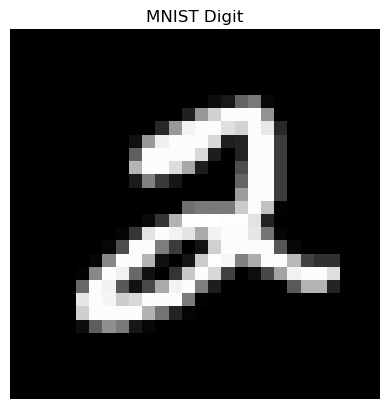

This is class 2.


In [3]:
import matplotlib.pyplot as plt
def visualize_mnist_row(row):
    """
    Visualizes a single MNIST image from a flattened matrix.
    """
    
    # Reshape from (784,) to (28, 28)
    image_array = row.reshape(28, 28)
    
    # Display the image
    plt.imshow(image_array, cmap='gray')
    plt.title(f"MNIST Digit")
    plt.axis('off')
    plt.show()

print(f'pics is of size {pics.shape} and targets is of size {targets.shape}')
INDEX=5
print(f'Visualizing the datapoint at index {INDEX}.')
visualize_mnist_row(pics[INDEX,:])
print(f'This is class {targets[INDEX]}.')

Now we're going to build a neural net that has ten output nodes - each will output the logit of one class.

In [4]:
class MnistClass(nn.Module):
    def __init__(self,width=10):
        super(MnistClass, self).__init__()
        self.hidden=nn.Linear(k,width)
        self.hidden_act=nn.ReLU()
        self.hidden2=nn.Linear(width,width)
        self.hidden2_act=nn.ReLU()
        self.output=nn.Linear(width,10)
    def forward(self,x):
        x=self.hidden(x)
        x=self.hidden_act(x)
        x=self.hidden2(x)
        x=self.hidden2_act(x)
        x=self.output(x)
        return x

We have to turn our data into tensors. The features need to be `float32`s, and the labels need to be `long`s. For the first time, we're also going to use the GPU, which is just one additional step. You have to explicitly move your data and your neural net model to the GPU. Running off the GPU will give you about a 20x speedup on training.

In [5]:
X=torch.tensor(pics,dtype=torch.float32).to('cuda')
y=torch.tensor(targets,dtype=torch.long).to('cuda') # Labels have to be "longs"
model=MnistClass(50).to('cuda')

We'll use `nn.CrossEntropyLoss`. This loss function expects that it will be given raw logits and integral class labels - it will apply softmax and turn the label into a probability distribution on your behalf.

In [6]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=.01)

### Training

In [7]:
EPOCHS=200
model.train()
for epoch in range(EPOCHS):
    predictions=model(X)
    loss=criterion(predictions,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch%20==0:
        print(f'epoch: {epoch} loss: {loss.item():.4f}')

epoch: 0 loss: 15.9280
epoch: 20 loss: 1.7256
epoch: 40 loss: 1.1611
epoch: 60 loss: 0.8531
epoch: 80 loss: 0.6593
epoch: 100 loss: 0.5287
epoch: 120 loss: 0.4632
epoch: 140 loss: 0.4212
epoch: 160 loss: 0.3875
epoch: 180 loss: 0.3602


### Making Predictions

OK, let's generate predictions for that digit above. To do this, I push the datapoint through the model, detach it, move it to the cpu (from the GPU), and then turn it into a numpy array.

In [8]:
model.eval()
with torch.no_grad():
    logits=model(X[INDEX,:]).detach().cpu().numpy()
print(logits)

[1.6620953 4.967818  8.644952  5.774959  0.336236  1.9512992 2.6386375
 5.1864123 6.102814  2.4171293]


The logit for class 2 is the largest, which is a good sign. Let's compute the softmax by hand, to get actual probabilities.

In [9]:
probs=np.exp(logits)/sum(np.exp(logits))
for i in range(10):
    print(f'{i}:',probs[i])

0: 0.00077367446
1: 0.021096734
2: 0.83401585
3: 0.047288142
4: 0.0002054683
5: 0.0010331369
6: 0.0020543057
7: 0.02625123
8: 0.06563537
9: 0.0016461343


There's a 79% chance that it's a 2. That's pretty good for this data point!

We could also use PyTorch's Softmax, rather than implementing it ourselves (of course the results are the same, I'm just showing you the technique):

In [10]:
model.eval()
with torch.no_grad():
    probs=nn.Softmax(dim=0)(model(X[INDEX,:]).detach()).to('cpu').numpy()
for i in range(10):
    print(f'{i}:',probs[i])

0: 0.0007736743
1: 0.021096736
2: 0.83401585
3: 0.04728815
4: 0.00020546833
5: 0.001033137
6: 0.0020543062
7: 0.026251232
8: 0.065635376
9: 0.0016461349


Let's make predictions for all 60,000 images. I'll print the predicted labels, and then the actual labels. The first one is wrong, the rest are correct.

In [11]:
model.eval()
with torch.no_grad():
    logits=model(X).detach().cpu().numpy()
predLabels=np.argmax(logits,axis=1)
print(predLabels)
print(targets)

[3 0 4 ... 5 6 8]
[5 0 4 ... 5 6 8]


Confusion matrix!

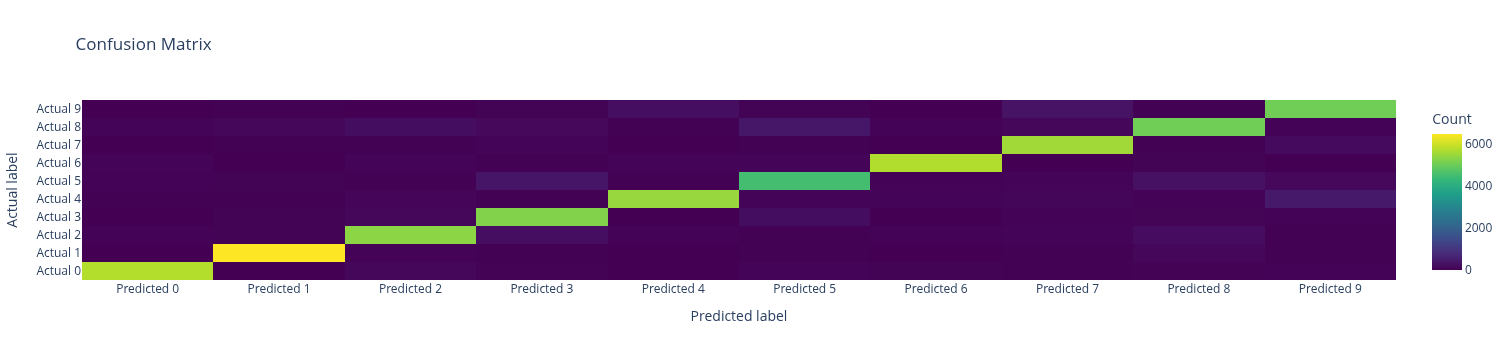

In [12]:
import sklearn
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(predLabels,targets)
import plotly.graph_objects as go
# Create a Plotly heatmap
fig = go.Figure(data=go.Heatmap(
    z=cm,
    x=[f'Predicted {i}' for i in range(cm.shape[0])],
    y=[f'Actual {i}' for i in range(cm.shape[0])],
    colorscale='Viridis',
    colorbar=dict(title='Count')
))

# Update layout
fig.update_layout(
    title='Confusion Matrix',
    xaxis_title='Predicted label',
    yaxis_title='Actual label',
)

# Show plot
fig.show()

## Train/Test splits

So far, we've just been using training data. Let's make a split, and demonstrate how we can compute train/test accuracy.

In [ ]:
from sklearn.model_selection import train_test_split
X = X.cpu()
y = y.cpu()
Xtr,Xte,ytr,yte=train_test_split(X,y)
model=MnistClass(50)

EPOCHS=1000

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=.001)

model = model.to('cuda')

Xtrain=Xtr.to('cuda')
Xtest=Xte.to('cuda')
ytrain=ytr.to('cuda')
ytest=yte.to('cuda')

for epoch in range(EPOCHS):
    model.train()
    predictions=model(Xtrain)
    loss=criterion(predictions,ytrain)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch%50==0:
        print(f'epoch: {epoch} training loss: {loss.item():.4f}')
        model.eval()
        with torch.no_grad():
            predictions=model(Xtest)
            test_loss=criterion(predictions,ytest)
            print(f'      testing loss: {test_loss.item():.4f}')

epoch: 0 training loss: 11.5356
      testing loss: 5.6866
epoch: 50 training loss: 0.3716
      testing loss: 0.3943
epoch: 100 training loss: 0.2417
      testing loss: 0.2822
epoch: 150 training loss: 0.1828
      testing loss: 0.2374
epoch: 200 training loss: 0.1463
      testing loss: 0.2127
epoch: 250 training loss: 0.1208
      testing loss: 0.1994
epoch: 300 training loss: 0.1018
      testing loss: 0.1918
epoch: 350 training loss: 0.0871
      testing loss: 0.1874
epoch: 400 training loss: 0.0753
      testing loss: 0.1849
epoch: 450 training loss: 0.0652
      testing loss: 0.1847
epoch: 500 training loss: 0.0565
      testing loss: 0.1859
epoch: 550 training loss: 0.0490
      testing loss: 0.1889
epoch: 600 training loss: 0.0426
      testing loss: 0.1930
epoch: 650 training loss: 0.0370
      testing loss: 0.1975


Training loss keeps dropping! Testing loss drops and then increases again! Boy, that sounds familiar.

## Datasets and DataLoaders

So far we've used raw tensors that could fit in memory. As datasets grow, we start to need `Dataset`s and `DataLoader`s.

In PyTorch, the transition from raw tensors to `Dataset` and `DataLoader` objects is necessitated by three primary constraints in production machine learning: memory management, data preprocessing, and batching efficiency.

**Memory Constraints:** While small datasets can reside entirely in GPU or CPU memory as a single matrix, real-world data (such as high-resolution video or large-scale text corpora) often exceeds hardware capacity. The `Dataset` abstraction allows for lazy loading, where individual samples are fetched from the disk only when required, preventing out-of-memory errors.

**The Dataset Abstraction:** A `Dataset` encapsulates the logic for accessing data. By implementing two methods—`__len__` and `__getitem__`—you can make the training loop look the same regardless of what weird data you have.

**The DataLoader and Minibatching:** The `DataLoader` acts as an iterator that wraps the `Dataset`. It automates the process of:
- Batching: Grouping individual samples into $N$-dimensional tensors for parallel processing.
- Shuffling: Randomizing data order at every epoch to prevent the model from learning the sequence of the data.
- Multiprocessing: Using multiple CPU workers to pre-fetch and transform data while the GPU is busy computing gradients, eliminating data-loading bottlenecks.

We don't need any of this for this small dataset, but let's demo it anyway.

In [ ]:
from torch.utils.data import Dataset

class MnistDataset(Dataset):
    def __init__(self,X,y):
        self.X=X
        self.y=y
    def __len__(self):
        n,_=self.X.shape
        return n
    def __getitem__(self,idx):
        return self.X[idx,:],self.y[idx]

trainingSet=MnistDataset(Xtr,ytr)
testingSet=MnistDataset(Xte,yte)

So that creates the Dataset. For example, if I now ask it for the fifth element of the training set, I get back that datapoint and that label due to the `__getitem__` function that overloads the indexing operator `[]`:

In [ ]:
point, label = trainingSet[5]
point = point.numpy()
label = label.numpy()
print(point.shape, label)
visualize_mnist_row(point)

We can then create `DataLoader`s for this, and rewrite our training loop to use batching. Notice how we loop over the Loaders to access all the data in an epoch.

In [ ]:
from torch.utils.data import DataLoader

trainLoader=DataLoader(trainingSet,batch_size=1000,shuffle=True)
testLoader=DataLoader(testingSet,batch_size=1000,shuffle=False)

model=MnistClass(50).to('cuda')

EPOCHS=100

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=.001)
for epoch in range(EPOCHS):
    model.train()
    totalloss=0
    for X,y in trainLoader:
        X = X.to('cuda')
        y = y.to('cuda')
        predictions=model(X)
        loss=criterion(predictions,y)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        totalloss+=loss.item()

    totalloss/=len(trainLoader)

    if (epoch+1) % 10 == 0:
        model.eval()
        test_loss=0
        with torch.no_grad():
            for X,y in testLoader:
                pred=model(X.to('cuda'))
                test_loss+=criterion(pred,y.to('cuda')).item()
            test_loss/=len(testLoader)
        print(f"Epoch {epoch}: Train Loss: {totalloss:.4f}, Test Loss: {test_loss:.4f}")